<a href="https://colab.research.google.com/github/MantaHonk/EOS_Weather_Data_Analysis/blob/main/Term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3><b>EOS 230 Term Project</b><h3>
<h1>Predicting YYJ International Airport's Daily Mean Temperature From Victoria, BC</h1>
<h4>Authored by Logan Saunderson<br><br><hr>

# Introduction

<h2>Background</h2>
This study was performed to determine whether data from Victoria Gonzales Weather Station could be used to predict the temperature of YYJ International Airport after its station's lifespan. We will determine the feasibility of using this station to predict the missing years of data for YYJ International Airport's station using statistical analysis.

<h4>Stations</h4>
Two stations were used, both located in the Capital Region District (Greater Victoria) of British Columbia (Fig. 1). As seen on the figure, YYJ International Airport is located southwest of Sidney. Victoria Gonzales Station is located just south of Oak Bay (labeled, just low quality).
YYJ's weather station has data collected from 1940-2013 and Victoria Gonzales is from 1973-2026. We will investigate the dataframes to determine the scale of our study and potential break points.

Figure 1: Map of Greater Victoria

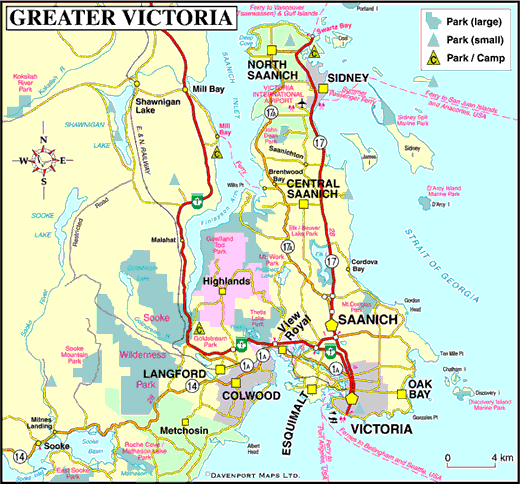

#Data ingest and EDA

We will now bring in the datasets from the weather stations and import Python libraries that we will use for our exploratory data analysis.

1. Data Collection

In [1]:
!git clone https://github.com/MantaHonk/EOS_Weather_Data_Analysis/

Cloning into 'EOS_Weather_Data_Analysis'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (19/19), done.
Receiving objects: 100% (20/20), 926.74 KiB | 13.24 MiB/s, done.
remote: Total 20 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Resolving deltas: 100% (6/6), done.


In [2]:
#Libraries
import pandas as pd
import plotly.express as px


In [3]:
folder_path = "/content/EOS_Weather_Data_Analysis"
df_a_stn_id = '1018620'
df_b_stn_id = '1018611'
#df_c_stn_id = '1018621'

#VG stands for Victoria Gonzales
df_YYJ = pd.read_parquet(f"{folder_path}/eccc_{df_a_stn_id}_daily.parquet")
df_VG = pd.read_parquet(f"{folder_path}/eccc_{df_b_stn_id}_daily.parquet")
#df_c = pd.read_parquet(f"{google_drive_folder_path}/eccc_{df_c_stn_id}_daily.parquet")

2. Data Cleaning

In [4]:
px.bar(df_YYJ[(df_YYJ['year'] >=2012) & (df_YYJ['year'] <= 2013)], x="timestamp", y="d_mean_temp", title = "YYJ Daily Mean Temperature (2011-2013)")

After checking the right end point of the YYJ data, we notice that the extent of 2013 is shortened to July 10th. Since the year is not complete, we will not consider 2013 for our analysis and use 2012 as our last year of interest.

As our goal is to predict future daily mean temperatures, we must consider a reasonable period of time to measure and collect data. We will use 3 complete years to make an accurate prediction while keeping resource use low and visualizations stable. We must now check for extreme values, anomalies, and missing data within the 2010-2012 extent for both datasets.



In [5]:
px.bar(df_YYJ[(df_YYJ['year'] >=2010) & (df_YYJ['year'] <= 2012)], x="timestamp", y="d_mean_temp", title = "YYJ Daily Mean Temperature (2010-2012)")

In [6]:
px.bar(df_VG[(df_VG['year'] >=2010) & (df_VG['year'] <= 2012)], x="timestamp", y="d_mean_temp", title = "Victoria Gonzales Daily Mean Temperature (2010-2012)")

In [7]:
df_YYJ[(df_YYJ['year'] >=2010) & (df_YYJ['year'] <= 2012)].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 25568 to 26663
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   lon               1096 non-null   float64       
 1   lat               1096 non-null   float64       
 2   station_name      1096 non-null   object        
 3   timestamp         1096 non-null   datetime64[ns]
 4   year              1096 non-null   int64         
 5   d_max_temp        1096 non-null   float64       
 6   d_min_temp        1096 non-null   float64       
 7   d_mean_temp       1096 non-null   float64       
 8   total_rain        1096 non-null   float64       
 9   total_snow        1096 non-null   float64       
 10  total_precip      1096 non-null   float64       
 11  snow_on_ground    1096 non-null   float64       
 12  source_year_file  1096 non-null   int64         
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 119.9+ KB


In [8]:
df_VG[(df_VG['year'] >=2010) & (df_VG['year'] <= 2012)].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 13514 to 14609
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   lon               1096 non-null   float64       
 1   lat               1096 non-null   float64       
 2   station_name      1096 non-null   object        
 3   timestamp         1096 non-null   datetime64[ns]
 4   year              1096 non-null   int64         
 5   d_max_temp        1090 non-null   float64       
 6   d_min_temp        1095 non-null   float64       
 7   d_mean_temp       1090 non-null   float64       
 8   total_rain        0 non-null      float64       
 9   total_snow        0 non-null      float64       
 10  total_precip      1081 non-null   float64       
 11  snow_on_ground    0 non-null      float64       
 12  source_year_file  1096 non-null   int64         
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 119.9+ KB


By the .info() method, we determine that there are no missing values within the YYJ dataframe, but there are 6 missing data points for the daily mean temperature of the Victoria Gonzales dataframe.
Our procedure for fixing this is to take the mean of the first left and right non-null entries and insert the values manually.

In [9]:
df_VG_2010_2012 = df_VG[(df_VG['year'] >= 2010) & (df_VG['year'] <= 2012)].copy()
df_VG_2010_2012['d_mean_temp'] = df_VG_2010_2012['d_mean_temp'].interpolate(method='linear', limit_direction='both')

df_VG.loc[df_VG_2010_2012.index, 'd_mean_temp'] = df_VG_2010_2012['d_mean_temp']

df_VG[(df_VG['year'] >=2010) & (df_VG['year'] <= 2012)].info()


<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 13514 to 14609
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   lon               1096 non-null   float64       
 1   lat               1096 non-null   float64       
 2   station_name      1096 non-null   object        
 3   timestamp         1096 non-null   datetime64[ns]
 4   year              1096 non-null   int64         
 5   d_max_temp        1090 non-null   float64       
 6   d_min_temp        1095 non-null   float64       
 7   d_mean_temp       1096 non-null   float64       
 8   total_rain        0 non-null      float64       
 9   total_snow        0 non-null      float64       
 10  total_precip      1081 non-null   float64       
 11  snow_on_ground    0 non-null      float64       
 12  source_year_file  1096 non-null   int64         
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 119.9+ KB


In [10]:
px.bar(df_VG[(df_VG['year'] >=2010) & (df_VG['year'] <= 2012)], x="timestamp", y="d_mean_temp", title = "Victoria Gonzales Daily Mean Temperature (2010-2012) (Cleaned)")

Now that the Victoria Gonzales data no longer contains null values, we can continue our EDA.

3. Summary Statistics
We will use a side-by-side boxplot to determine how similar the two stations are, by analyzing outliers and quantiles of the stations.

In [11]:
mask_yyj = (df_YYJ['year'] >= 2010) & (df_YYJ['year'] <= 2012)
mask_vg = (df_VG['year'] >= 2010) & (df_VG['year'] <= 2012)
df_yyj_t = df_YYJ.loc[mask_yyj, ['timestamp', 'd_mean_temp']].rename(columns={'d_mean_temp': 'temp_yyj'})
df_vg_t = df_VG.loc[mask_vg, ['timestamp', 'd_mean_temp']].rename(columns={'d_mean_temp': 'temp_gonzales'})
df_overlap = pd.merge(df_yyj_t, df_vg_t, on='timestamp')

fig = px.box(
    df_overlap,
    y=["temp_gonzales", "temp_yyj"],
    title="Temperature Distribution: Gonzales vs. YYJ (2010-2012)",
    labels={
        "value": "Temperature (°C)",
        "variable": "Weather Station"
    },
    template="plotly_white"
)

fig.show()

4. Correlation Analysis

We will use a scatterplot and plot daily mean temperatures for both of the data sets. From this, we will find the R^2 value and determine if there is any correlation between the two stations.

In [12]:
fig = px.scatter(
    df_overlap,
    x="temp_gonzales",
    y="temp_yyj",
    trendline="ols",
    title="Temperature Correlation: Gonzales vs. YYJ (2010-2012)",
    labels={
        "temp_gonzales": "Victoria Gonzales Mean Temp (°C)",
        "temp_yyj": "YYJ Airport Mean Temp (°C)"
    },
    hover_data=["timestamp"],
    template="plotly_white"
)

fig.show()

results = px.get_trendline_results(fig)
model = results.iloc[0]["px_fit_results"]
print(f"R-Squared: {model.rsquared:.4f}")
print(f"Slope: {model.params[1]:.4f}")

R-Squared: 0.9410
Slope: 1.1508
